## Alphabet Inc. (Google) (GOOG)  Exploratory Data Analysis

### Overview
This notebook presents an exploratory data analysis (EDA) of financial news headlines related to **Alphabet Inc. (Google) (GOOG)**. The analysis is part of a broader project at **Nova Financial Solutions** aimed at building a predictive analytics pipeline that connects market narratives to stock price movements.

### Objectives
- Understand the structure and statistical properties of the financial news dataset
- Identify common keywords, themes, and topics in GOOG-related headlines
- Analyze publication trends and volume spikes over time
- Examine publisher activity and contribution patterns

### Dataset
The analysis uses the **Financial News and Stock Price Integration Dataset (FNSPID)**, which contains financial news headlines, publication dates, publisher information, and associated stock ticker symbols.

## 1. Import Libraries

In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from src.data_loader import load_news_data, filter_by_stock
from src.text_analyzer import (
    clean_headline,
    get_tfidf_keywords,
    get_word_frequency,
    get_lda_topics,
    extract_email_domains
)
from src.visualizer import (
    plot_headline_length,
    plot_publisher_activity,
    plot_email_domains,
    plot_time_series,
    plot_keywords,
    plot_lda_topics
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ All libraries imported successfully!


## 2. Loading the Data

We load the raw financial news dataset using our modular `load_news_data()` function from `src/data_loader.py`. This keeps our notebook clean and ensures consistent data loading across all notebooks.

In [16]:
df = load_news_data('../data/raw/raw_analyst_ratings.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

✅ Loaded 1407328 news articles.
Dataset Shape: (1407328, 5)

Column Names: ['headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


## 3. Data Filtering

We filter the dataset for **GOOG** articles only using our modular `filter_by_stock()` function. The cleaning was already handled inside `load_news_data()`.

In [17]:
goog_df = filter_by_stock(df, 'GOOG')

print(f"\nDate range: {goog_df['date'].min().date()} to {goog_df['date'].max().date()}")
print(f"\nMissing values:\n{goog_df.isnull().sum()}")
goog_df.head()

✅ Found 1199 articles for GOOG.

Date range: 2018-11-13 to 2020-06-10

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13+00:00,GOOG
1,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50+00:00,GOOG
2,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00+00:00,GOOG
3,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 18:39:26+00:00,GOOG
4,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 07:51:41+00:00,GOOG


## 4. Descriptive Statistics

In this section we examine the basic statistical properties of the dataset including headline length distribution, article count over time, and a general summary of the data.

In [18]:
goog_df['headline_length'] = goog_df['headline'].apply(len)

print("=== Headline Length Statistics ===")
print(goog_df['headline_length'].describe())

print(f"\n=== Sample Headlines ===")
for h in goog_df['headline'].sample(5, random_state=42).values:
    print(f"• {h}")

=== Headline Length Statistics ===
count    1199.000000
mean       86.687239
std        46.697582
min        18.000000
25%        57.000000
50%        75.000000
75%        95.000000
max       315.000000
Name: headline_length, dtype: float64

=== Sample Headlines ===
• YouTube Unit Of Alphabet Inc's Google Says Aims To Make All Future Original Programming Ad-Supported; Say Strategy Shift Follows Global User And Advertiser Demand
• Google CEO Sundar Pichai Was In Oklahoma To Announce A $600M Investment To Expand Data Center In Mayes County
• Alphabet, Boeing Shares Get A Lift Following Earnings, While GE Falls Short
• Google Will Scrap Dutch, Irish IP Licensing System, Will Return IP To US
• VMWare Announces Creation Of Next-Gen SOC Alliance With Splunk, IBM Security, Google Cloud's Chronicle, Exabeam And Sumo Logic


### 4.1 Headline Length Distribution

We visualize the distribution of headline character lengths to understand how concise or verbose the financial news headlines tend to be.

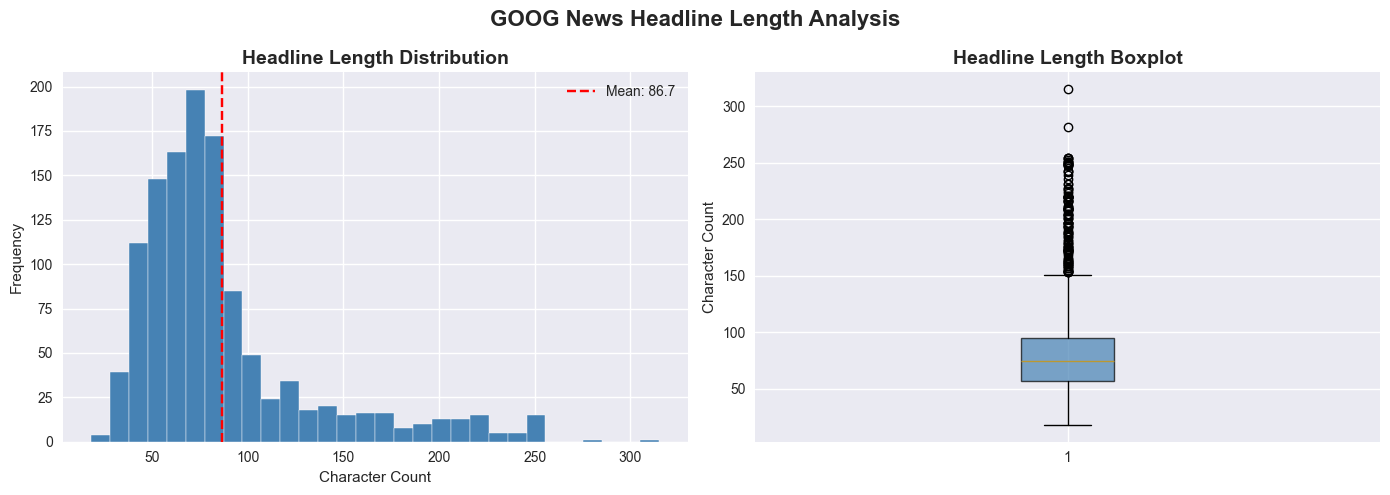

In [19]:
plot_headline_length(goog_df, 'GOOG')

## 5. Publisher Analysis

We identify the most active publishers contributing to GOOG-related news. Understanding which sources dominate the coverage helps assess potential bias and the diversity of market perspectives.

In [20]:
publisher_counts = goog_df['publisher'].value_counts()

print(f"Total unique publishers: {publisher_counts.nunique()}")
print(f"\nTop 10 most active publishers:")
print(publisher_counts.head(10))

Total unique publishers: 22

Top 10 most active publishers:
publisher
Benzinga Newsdesk    470
Neer Varshney         68
JJ Kinahan            68
Wayne Duggan          64
Jayson Derrick        52
Lisa Levin            52
Charles Gross         41
Dave Royse            35
ETF Professor         32
Shivdeep Dhaliwal     27
Name: count, dtype: int64


### 5.1 Publisher Activity Visualization

The bar chart below highlights the dominance of certain publishers in GOOG news coverage, particularly **Benzinga Newsdesk** which accounts for the majority of articles.

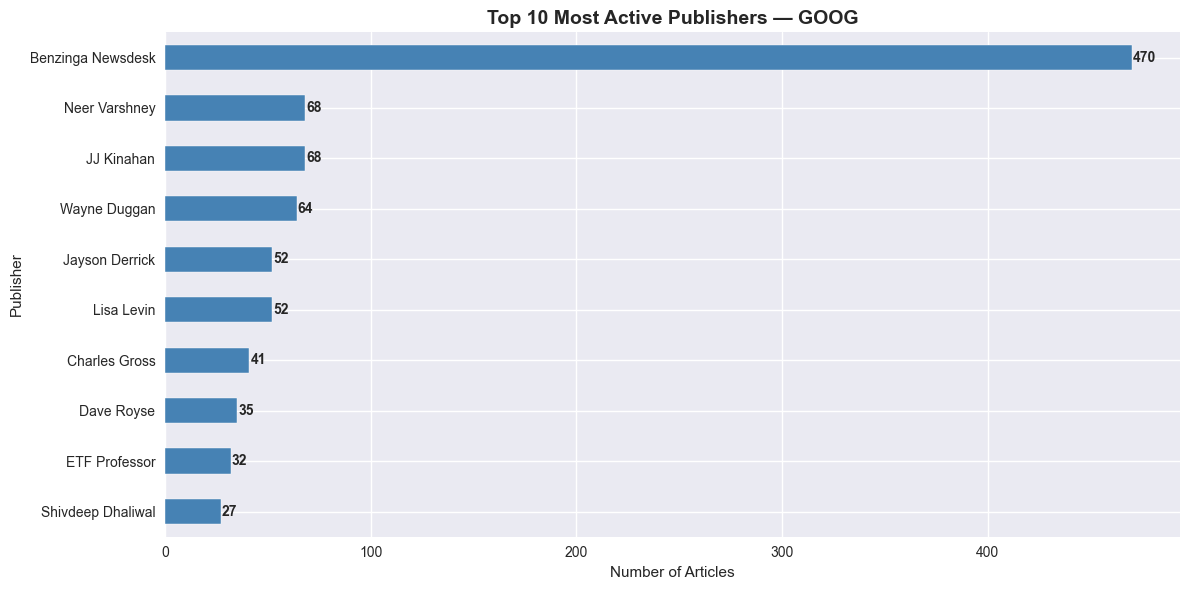

In [21]:
plot_publisher_activity(publisher_counts, 'GOOG')

### 5.2 Email Publisher Domain Analysis

Some publishers use email addresses as their names. We extract the domain from these emails to identify the organizations contributing to the news coverage.

Articles from email-based publishers: 9
Unique email publishers: 3

Top domains:
         domain  count
0  benzinga.com      9


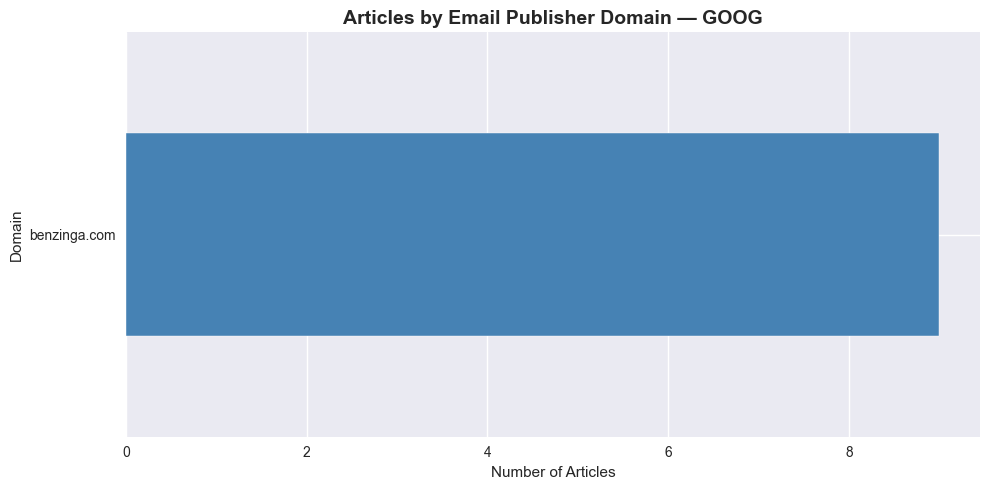

In [22]:
email_pubs = goog_df[goog_df['publisher'].str.contains('@', na=False)]
print(f"Articles from email-based publishers: {len(email_pubs)}")
print(f"Unique email publishers: {email_pubs['publisher'].nunique()}")

domain_counts = extract_email_domains(goog_df)
print(f"\nTop domains:\n{domain_counts}")

plot_email_domains(domain_counts, 'GOOG')

## 6. Time Series Analysis of News Volume

We analyze how GOOG-related article publication frequency varies over time. Spikes in news volume often correlate with significant market events such as earnings releases, product launches, or macroeconomic developments.

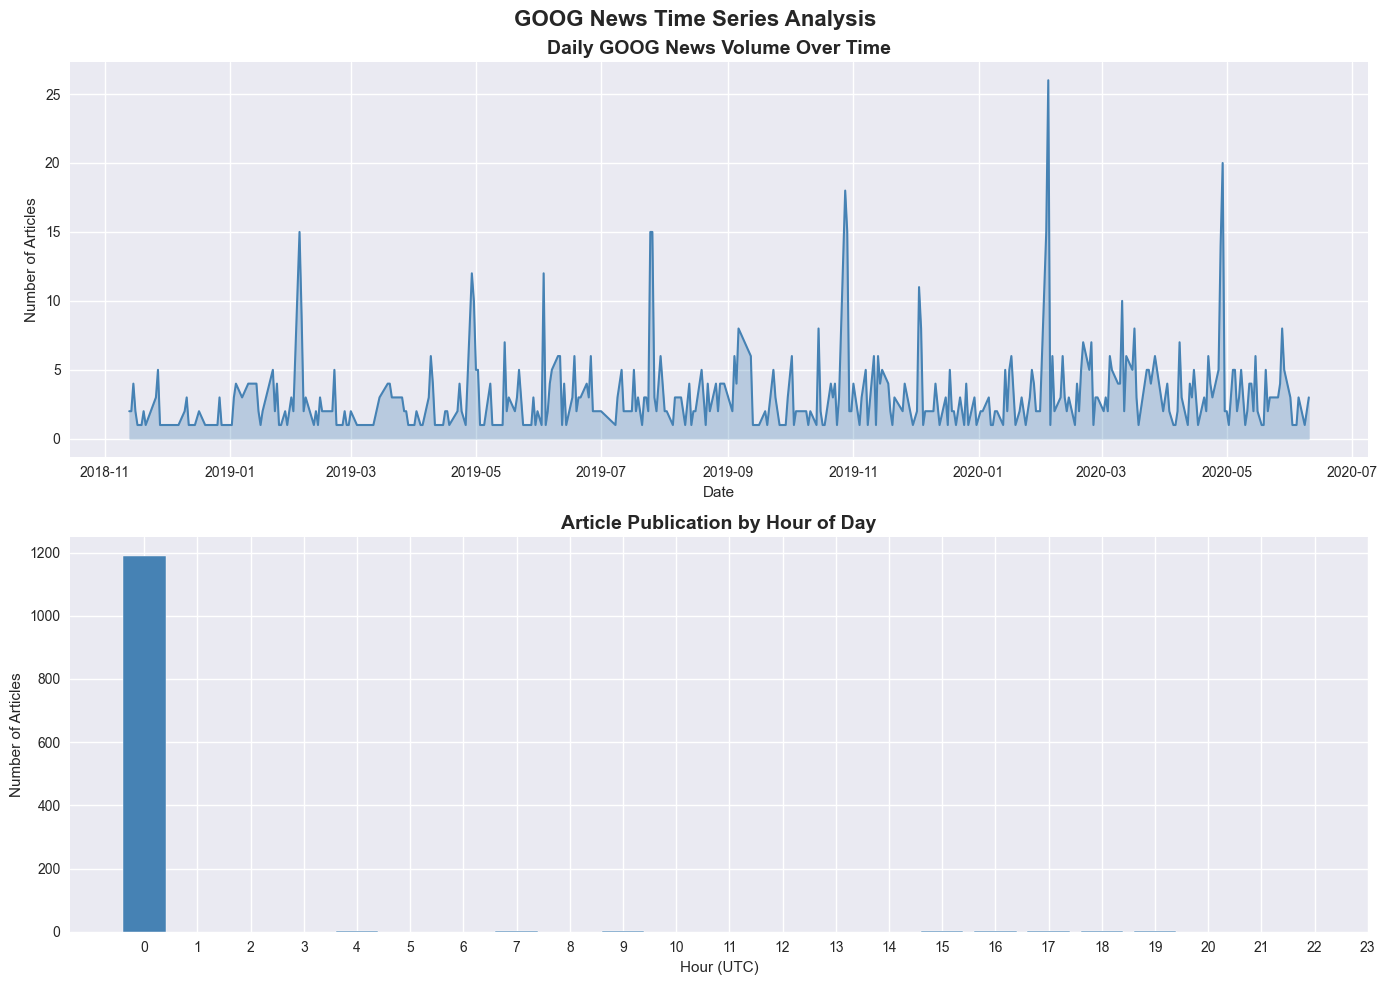

In [23]:
goog_df['date_only'] = goog_df['date'].dt.date
goog_df['hour'] = goog_df['date'].dt.hour
goog_df['day_of_week'] = goog_df['date'].dt.day_name()

daily_counts = goog_df.groupby('date_only').size()

plot_time_series(goog_df, daily_counts, 'GOOG')

## 7. Text Analysis & Topic Modeling

We apply NLP techniques to extract the most frequent keywords and themes from GOOG-related headlines using three complementary approaches: **TF-IDF**, **CountVectorizer**, and **LDA Topic Modeling**.

In [24]:
goog_df['cleaned_headline'] = goog_df['headline'].apply(clean_headline)

tfidf_matrix, tfidf_keywords, tfidf_scores = get_tfidf_keywords(
    goog_df['cleaned_headline'])
word_freq = get_word_frequency(goog_df['cleaned_headline'])

print("Top 20 Keywords (TF-IDF):")
print(tfidf_keywords)
print(f"\nTop 20 Keywords (Frequency):")
print(word_freq)

Top 20 Keywords (TF-IDF):
['alphabet' 'amazon' 'apple' 'cloud' 'companies' 'coronavirus' 'earnings'
 'facebook' 'google' 'maintains' 'market' 'new' 'says' 'shares' 'stocks'
 'target' 'tech' 'trading' 'week' 'youtube']

Top 20 Keywords (Frequency):
        keyword  frequency
8        google        407
0      alphabet        174
12         says        123
14       stocks        101
13       shares         99
6      earnings         85
3         cloud         77
19      youtube         68
10       market         62
16         tech         62
17      trading         59
5   coronavirus         58
15       target         57
7      facebook         56
11          new         52
2         apple         52
4     companies         46
1        amazon         42
9     maintains         41
18         week         41


### 7.1 Top Keywords Visualization

The most frequently occurring keywords reveal the dominant themes in GOOG news coverage. Notable themes include YouTube and cloud computing growth, big tech sector competition with frequent mentions of Apple, Amazon and Facebook, and earnings performance — reflecting Alphabet's position as a key player in the broader technology sector during early 2020.

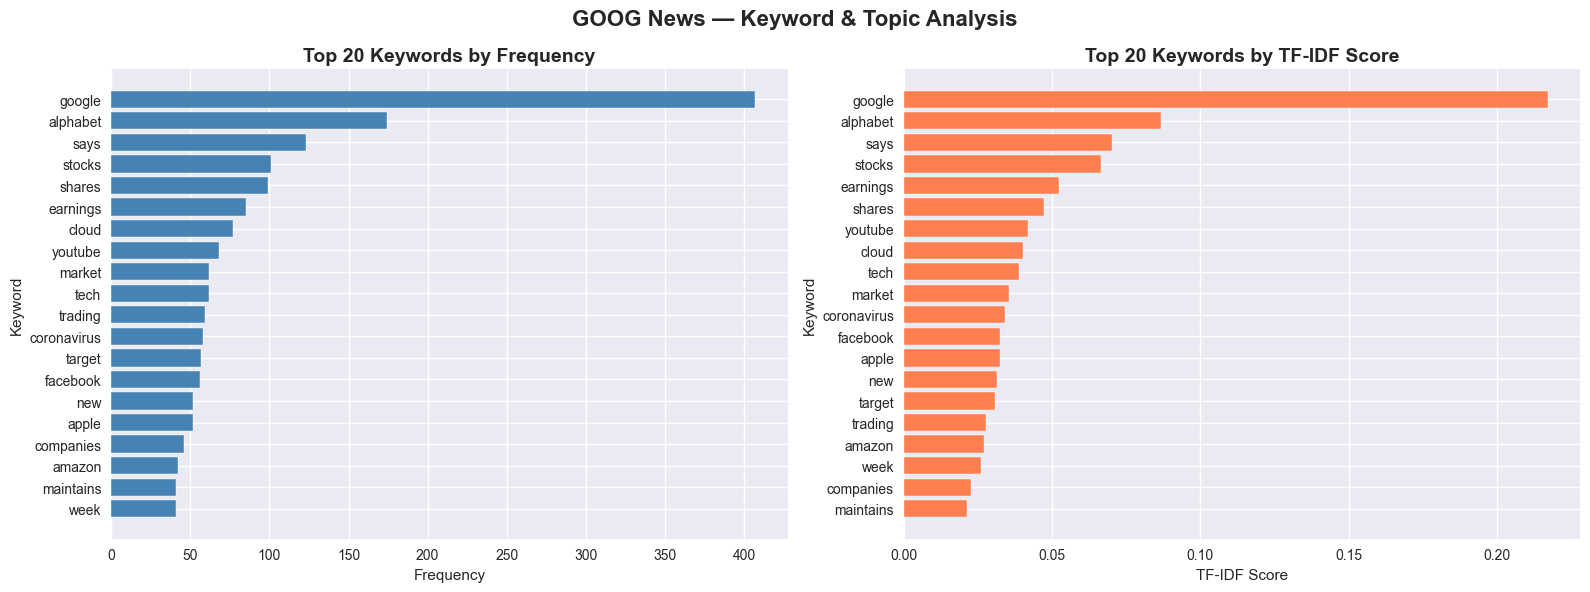

In [25]:
plot_keywords(word_freq, tfidf_keywords, tfidf_scores, 'GOOG')

### 7.2 LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is an unsupervised machine learning technique that discovers hidden topics in a collection of documents. We use LDA to identify the main themes discussed in GOOG-related headlines.

=== LDA Topic Modeling Results ===
Number of topics: 5

Topic 1: google, earnings, alphabet, tech, apple, new, says, youtube, amazon, could
Topic 2: google, alphabet, target, says, maintains, price, buy, raises, trump, update
Topic 3: google, cloud, youtube, stocks, earnings, stadia, report, announces, says, money
Topic 4: shares, trading, market, stocks, companies, several, lower, coronavirus, higher, technology
Topic 5: google, antitrust, says, week, alphabet, probe, apple, stocks, justice, ceo


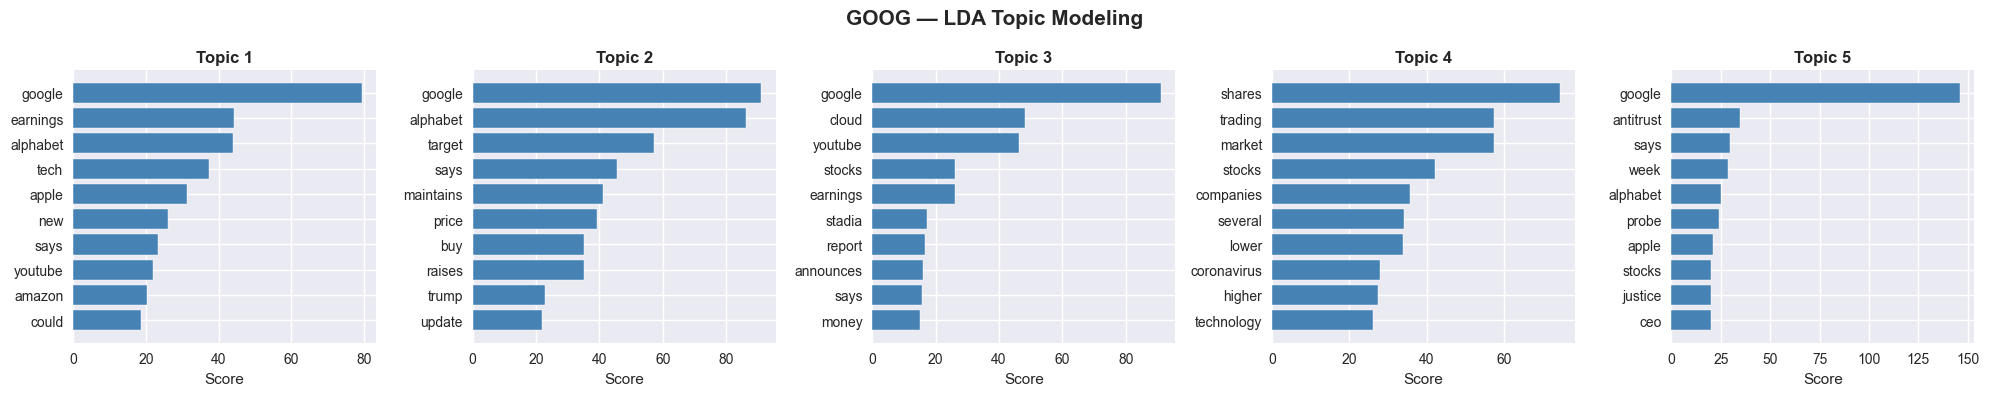

In [26]:
lda_model, feature_names, topics = get_lda_topics(
    goog_df['cleaned_headline'], n_topics=5)

print("=== LDA Topic Modeling Results ===")
print(f"Number of topics: 5\n")
for i, topic in enumerate(topics):
    print(f"Topic {i+1}: {', '.join(topic)}")

plot_lda_topics(lda_model, feature_names, 5, 'GOOG')

## 8. Key Findings & Summary

A summary of the most important insights derived from the exploratory data analysis of GOOG-related financial news headlines.

In [27]:
print("=" * 55)
print("        GOOG EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
📰 DATASET OVERVIEW
- Total GOOG articles analyzed : {len(goog_df)}
- Date range                   : {goog_df['date'].min().date()} to {goog_df['date'].max().date()}
- Unique publishers            : {goog_df['publisher'].nunique()}

📏 HEADLINE STATISTICS
- Average headline length      : {goog_df['headline_length'].mean():.1f} characters
- Shortest headline            : {goog_df['headline_length'].min()} characters
- Longest headline             : {goog_df['headline_length'].max()} characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : {goog_df['publisher'].value_counts().index[0]}
- Articles by top publisher    : {goog_df['publisher'].value_counts().iloc[0]}

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : {daily_counts.max()} articles
- Date of highest volume       : {daily_counts.idxmax()}

🔑 TOP THEMES IDENTIFIED
- YouTube & cloud computing growth
- Big tech sector competition (Apple, Amazon, Facebook)
- Earnings performance & revenue analysis
- COVID-19 impact on advertising revenue
- Stock trading & investor sentiment
""")
print("=" * 55)

        GOOG EDA — KEY FINDINGS SUMMARY

📰 DATASET OVERVIEW
- Total GOOG articles analyzed : 1199
- Date range                   : 2018-11-13 to 2020-06-10
- Unique publishers            : 72

📏 HEADLINE STATISTICS
- Average headline length      : 86.7 characters
- Shortest headline            : 18 characters
- Longest headline             : 315 characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : Benzinga Newsdesk
- Articles by top publisher    : 470

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : 26 articles
- Date of highest volume       : 2020-02-04

🔑 TOP THEMES IDENTIFIED
- YouTube & cloud computing growth
- Big tech sector competition (Apple, Amazon, Facebook)
- Earnings performance & revenue analysis
- COVID-19 impact on advertising revenue
- Stock trading & investor sentiment



## 9. Conclusion

The EDA of GOOG financial news reveals the largest dataset among the analyzed companies, reflecting Alphabet's broad media presence. Coverage during **(2020)** was heavily focused on **YouTube growth**, **Google Cloud expansion**, and the **broader big tech narrative** — frequently mentioning competitors like Apple, Amazon, and Facebook.

**Benzinga Newsdesk** remains the dominant publisher. The frequent appearance of `earnings` and `cloud` suggests analysts were closely watching Alphabet's ability to maintain revenue growth despite COVID-19's impact on digital advertising.

These insights will inform the sentiment analysis and correlation study in the subsequent notebook.